<a href="https://colab.research.google.com/github/sreelakshmikv123/Feature-Extaction/blob/main/Feature_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install opencv-python scikit-image

In [5]:
from google.colab import files
uploaded = files.upload()

Saving group-photo.webp to group-photo.webp


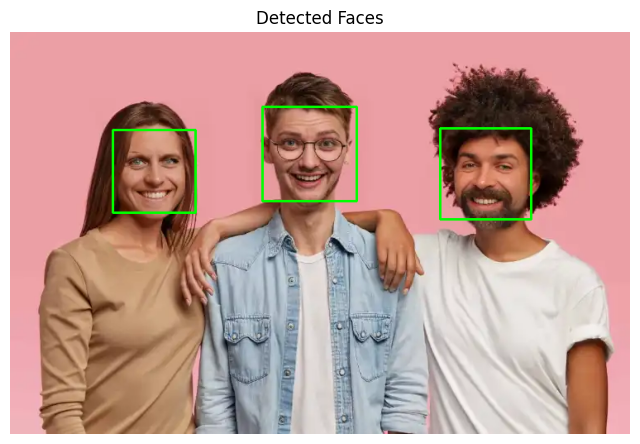

Number of faces detected: 3
Feature vector shape: (3, 4356)


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Read image
img = cv2.imread('group-photo.webp')   # change filename if needed
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

features = []   # to store face features

# Process each detected face
for (x, y, w, h) in faces:
    face = gray[y:y+h, x:x+w]              # crop
    face_resized = cv2.resize(face, (100, 100))  # resize

    # Extract HOG features
    hog_features = hog(
        face_resized,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    features.append(hog_features)

# Convert to NumPy array
features = np.array(features)

# Display results
plt.figure(figsize=(8, 6))
for (x, y, w, h) in faces:
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.imshow(img_rgb)
plt.axis('off')
plt.title("Detected Faces")
plt.show()

# Output details
print("Number of faces detected:", len(faces))
print("Feature vector shape:", features.shape)
